## Imports

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
from plotly.subplots import make_subplots
import seaborn

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE 
import umap
from scipy.stats import pearsonr

import PyWGCNA

/Users/daniel.hosomi/csvd-projects/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/daniel.hosomi/csvd-projects/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


## Configurações

In [2]:
PROCESSED_DIR = Path("../../data/interim")
DESEQ_DIR = Path("../../data/interim/deseq2")
LOGCPM_PATH = PROCESSED_DIR / "microplastic_logcpm_filtered.csv"
METADATA_PATH = PROCESSED_DIR / "microplastic_metadata.csv"
WGCNA_INPUT_PATH = PROCESSED_DIR / "microplastic_vst_wgcna_input.csv"

# Saídas
WGCNA_DIR = Path("../../data/interim/wgcna")
WGCNA_DIR.mkdir(parents=True, exist_ok=True)

GENE_MODULES_PATH = WGCNA_DIR / "wgcna_gene_modules.csv"
MODULE_EIGENGENES_PATH = WGCNA_DIR / "wgcna_module_eigengenes.csv"
MODULE_EIGENGENES_TREATED_PATH = WGCNA_DIR / "wgcna_module_eigengenes_treated.csv"
MODULE_TRAIT_CORR_PATH = WGCNA_DIR / "wgcna_module_trait_correlations_treated.csv"
MODULE_TRAIT_PVAL_PATH = WGCNA_DIR / "wgcna_module_trait_pvalues_treated.csv"
MODULE_SUMMARY_PATH = WGCNA_DIR / "wgcna_module_summary.csv"

HEATMAP_PATH = WGCNA_DIR / "wgcna_module_trait_heatmap_treated.png"

## Carregamento dos Dados de DEG

In [3]:
vst_df = pd.read_csv(WGCNA_INPUT_PATH)
metadata_df = pd.read_csv(METADATA_PATH)

print("VST:", vst_df.shape)
print("metadata:", metadata_df.shape)

display(vst_df.head())
display(metadata_df.head())

VST: (12174, 25)
metadata: (24, 9)


,gene_id,CTR_1,CTR_2,CTR_3,MA1_1,MA1_2,MA1_3,MA100_1,MA100_2,MA100_3,...,MB100_3,MC1_1,MC1_2,MC1_3,MC100_1,MC100_2,MC100_3,MD1_1,MD1_2,MD1_3
0,ENSG00000000003,8.495462,8.450681,8.523000,8.361693,7.986612,8.218316,8.322836,8.369257,8.097211,...,8.616483,8.007643,8.065576,8.290587,8.234527,8.321764,8.461571,8.085981,8.451195,8.256791
1,ENSG00000000419,9.602250,8.919754,9.676562,9.491573,9.459700,9.228012,9.421966,9.663061,9.276540,...,9.537103,8.938840,9.487930,9.166494,9.461464,9.762872,9.298874,9.329732,9.573834,9.781742
2,ENSG00000000457,4.818618,6.950606,5.152469,4.995176,5.243716,4.919546,4.882649,5.203948,2.789318,...,5.716236,4.926155,3.928253,4.571468,5.347044,5.944513,5.911113,5.399056,5.222412,5.447777
3,ENSG00000000460,5.259300,4.897526,3.138399,2.524263,2.720120,4.958863,4.835425,2.160350,0.000000,...,4.540396,4.689803,5.272439,4.159591,3.657667,4.300867,4.913910,1.979153,4.745030,0.000000
4,ENSG00000001036,9.949776,9.975952,10.080303,9.906705,9.953352,10.599921,10.022790,9.818998,9.955213,...,10.260942,9.887857,9.942680,10.025102,10.283438,10.236575,10.253528,10.044966,10.216139,10.036049


,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,sample_id,group,replicate
0,control,NaN,NaN,0.0,True,control,CTR_1,CTR,1
1,control,NaN,NaN,0.0,True,control,CTR_2,CTR,2
2,control,NaN,NaN,0.0,True,control,CTR_3,CTR,3
3,polystyrene,1.0,1000.0,0.1,False,treated,MA1_1,MA1,1
4,polystyrene,1.0,1000.0,0.1,False,treated,MA1_2,MA1,2


## Construção do WGCNA

In [4]:
# Preparação da matriz de expressão para PyWGCNA.
# A matriz em arquivo está em genes x amostras.
# Para o construtor WGCNA do PyWGCNA, deve-se usar amostras x genes.

sample_ids = metadata_df["sample_id"].tolist()
expr_sample_cols = [c for c in vst_df.columns if c != "gene_id"]

missing_in_expr = sorted(set(sample_ids) - set(expr_sample_cols))
missing_in_meta = sorted(set(expr_sample_cols) - set(sample_ids))

if missing_in_expr or missing_in_meta:
    raise ValueError(
        f"Inconsistência entre expressão e metadata.\n"
        f"Ausentes na expressão: {missing_in_expr}\n"
        f"Ausentes no metadata: {missing_in_meta}"
    )

# Reordena as colunas conforme a ordem do metadata
vst_df = vst_df[["gene_id"] + sample_ids]

# Formato esperado para WGCNA: amostras x genes
expr_wgcna = vst_df.set_index("gene_id").T
expr_wgcna.index.name = "sample_id"

# Metadata alinhado
metadata = metadata_df.set_index("sample_id").loc[expr_wgcna.index].copy()

print("Matriz para WGCNA:", expr_wgcna.shape)
print("Metadata alinhado:", metadata.shape)

display(expr_wgcna.iloc[:5, :5])
display(metadata.head())

Matriz para WGCNA: (24, 12174)
Metadata alinhado: (24, 8)


gene_id,ENSG00000000003,ENSG00000000419,ENSG00000000457,ENSG00000000460,ENSG00000001036
sample_id,,,,,
CTR_1,8.495462,9.602250,4.818618,5.259300,9.949776
CTR_2,8.450681,8.919754,6.950606,4.897526,9.975952
CTR_3,8.523000,9.676562,5.152469,3.138399,10.080303
MA1_1,8.361693,9.491573,4.995176,2.524263,9.906705
MA1_2,7.986612,9.459700,5.243716,2.720120,9.953352


,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,group,replicate
sample_id,,,,,,,,
CTR_1,control,NaN,NaN,0.0,True,control,CTR,1
CTR_2,control,NaN,NaN,0.0,True,control,CTR,2
CTR_3,control,NaN,NaN,0.0,True,control,CTR,3
MA1_1,polystyrene,1.0,1000.0,0.1,False,treated,MA1,1
MA1_2,polystyrene,1.0,1000.0,0.1,False,treated,MA1,2


In [5]:
# Preparação do metadata para PyWGCNA.

# Corrige possíveis problemas de tipo ao ler CSV
if metadata["is_control"].dtype == object:
    metadata["is_control"] = metadata["is_control"].astype(str).str.lower().map({
        "true": True,
        "false": False
    })

metadata["particle_size_um"] = pd.to_numeric(metadata["particle_size_um"], errors="coerce")
metadata["particle_size_nm"] = pd.to_numeric(metadata["particle_size_nm"], errors="coerce")
metadata["concentration_gL"] = pd.to_numeric(metadata["concentration_gL"], errors="coerce")

display(metadata.dtypes)
display(metadata.head())

particle_type        object
particle_size_um    float64
particle_size_nm    float64
concentration_gL    float64
is_control             bool
treatment_status     object
group                object
replicate             int64
dtype: object

,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,group,replicate
sample_id,,,,,,,,
CTR_1,control,NaN,NaN,0.0,True,control,CTR,1
CTR_2,control,NaN,NaN,0.0,True,control,CTR,2
CTR_3,control,NaN,NaN,0.0,True,control,CTR,3
MA1_1,polystyrene,1.0,1000.0,0.1,False,treated,MA1,1
MA1_2,polystyrene,1.0,1000.0,0.1,False,treated,MA1,2


In [6]:
# Construção do objeto WGCNA

pyw = PyWGCNA.WGCNA(
    name="microplastic_wgcna",
    species="human",
    geneExp=expr_wgcna,
    sampleInfo=metadata,
    outputPath=str(WGCNA_DIR),
    save=True,
    TPMcutoff=0,
    powers=list(range(1, 11)) + list(range(12, 22, 2)),
    RsquaredCut=0.8,
    MeanCut=100,
    networkType="signed hybrid",
    TOMType="signed",
    minModuleSize=50,
    MEDissThres=0.2,
)

Saving data to be True, checking requirements ...
Figure directory does not exist!
Creating figure directory!


Pre-processing...
	Detecting genes and samples with too many missing values...
	Done pre-processing..

Run WGCNA...
pickSoftThreshold: calculating connectivity for given powers...
will use block size  3674
    Power  SFT.R.sq     slope truncated R.sq      mean(k)    median(k)  \
0       1  0.440008 -2.278582       0.863196  1301.785542  1224.985265   
1       2  0.821173 -2.124055       0.943778   436.924026   368.276101   
2       3  0.927927 -1.972302        0.97472   185.288956   134.230083   
3       4  0.954907 -1.846666        0.98283    91.556997    55.866167   
4       5  0.946464 -1.776876       0.973254    50.487652    25.402623   
5       6   0.95132 -1.703454       0.980218    30.241614    12.386622   
6       7  0.954515 -1.642328       0.983453    19.317683     6.381577   
7       8    0.9462 -1.608553       0.977991    12.986824     3.450687   
8       9  0.936524 -1.578275       0.976091     9.099289     1.933259   
9      10  0.940309 -1.543831       0.979986     6.595

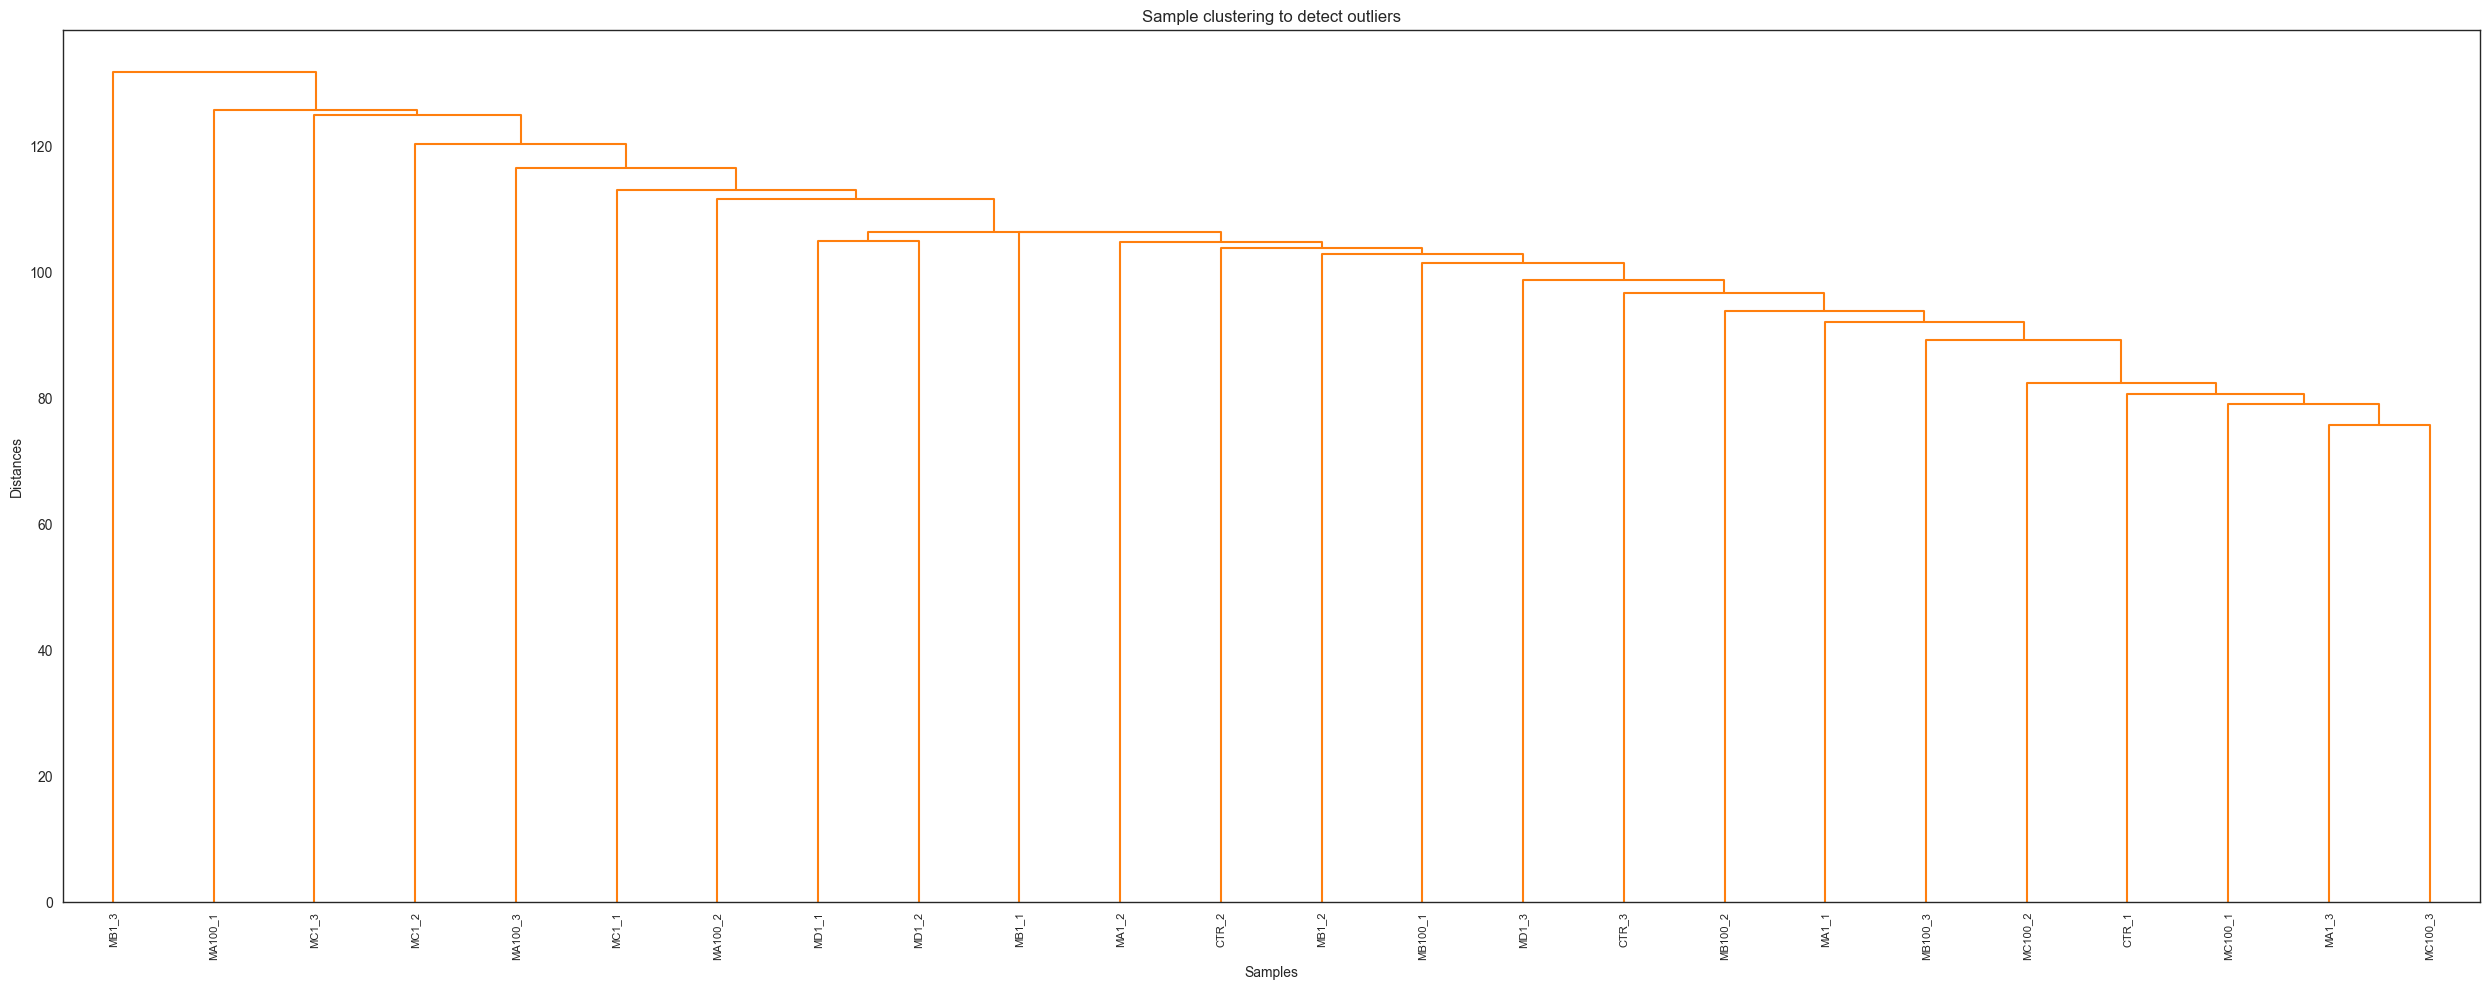

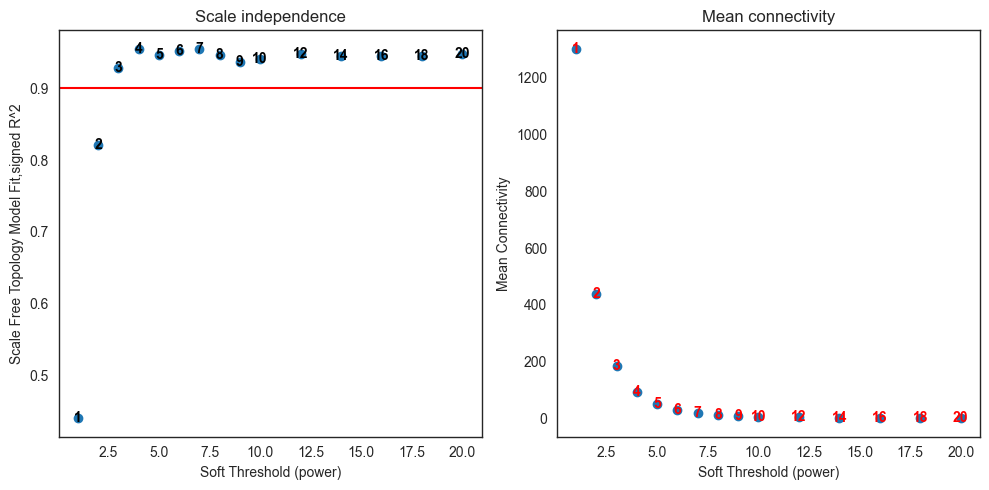

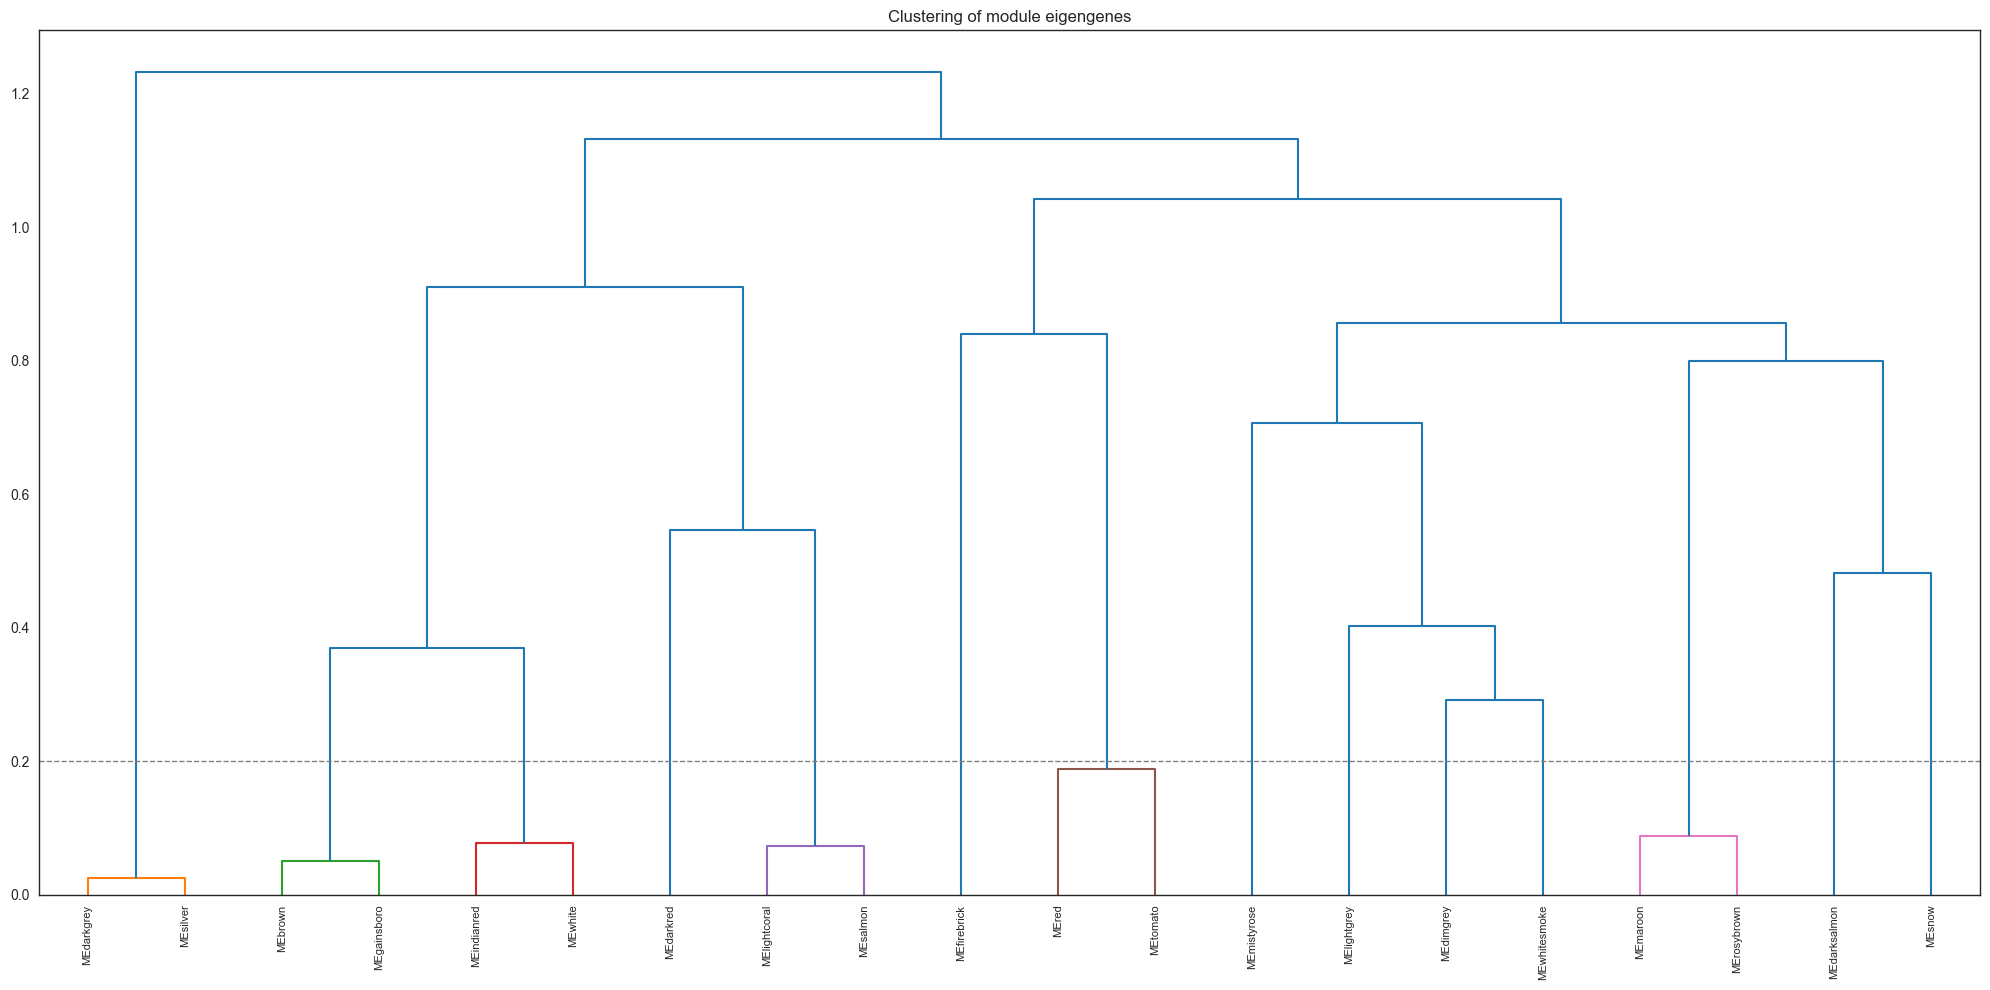

In [7]:
# Rodar WGCNA

pyw.runWGCNA()

if hasattr(pyw, "saveWGCNA"):
    pyw.saveWGCNA()

print("WGCNA executada com sucesso.")

## Inspeção dos Resultados

In [8]:
# Verificar os principais atributos do objeto PyWGCNA após a execução

print("type(pyw.datExpr):", type(getattr(pyw, "datExpr", None)))
print("shape datExpr:", getattr(getattr(pyw, "datExpr", None), "shape", None))

if hasattr(pyw, "datExpr") and pyw.datExpr is not None:
    print("var columns:", pyw.datExpr.var.columns)
    display(pyw.datExpr.var.head())

type(pyw.datExpr): <class 'anndata._core.anndata.AnnData'>
shape datExpr: (24, 12174)
var columns: Index(['dynamicColors', 'moduleColors', 'moduleLabels'], dtype='object')


,dynamicColors,moduleColors,moduleLabels
gene_id,,,
ENSG00000000003,dimgrey,dimgrey,4
ENSG00000000419,dimgrey,dimgrey,4
ENSG00000000457,dimgrey,dimgrey,4
ENSG00000000460,dimgrey,dimgrey,4
ENSG00000001036,dimgrey,dimgrey,4


In [9]:
# Extração de genes e módulos finais obtidos com WGCNA

if not hasattr(pyw, "datExpr") or pyw.datExpr is None:
    raise ValueError("pyw.datExpr não está disponível.")

gene_var = pyw.datExpr.var.copy()

expected_cols = {"dynamicColors", "moduleColors", "moduleLabels"}
missing_cols = expected_cols - set(gene_var.columns)

if missing_cols:
    raise ValueError(f"Colunas esperadas ausentes em pyw.datExpr.var: {missing_cols}")

gene_modules_df = (
    gene_var
    .reset_index()
    .rename(columns={"index": "gene_id"})
    [["gene_id", "dynamicColors", "moduleColors", "moduleLabels"]]
    .copy()
)

gene_modules_df = gene_modules_df.rename(columns={
    "dynamicColors": "dynamic_module",
    "moduleColors": "module",
    "moduleLabels": "module_label"
})

gene_modules_df.to_csv(GENE_MODULES_PATH, index=False)

print("Tabela gene -> módulo salva em:", GENE_MODULES_PATH)
print("Dimensões:", gene_modules_df.shape)

display(gene_modules_df.head())
display(
    gene_modules_df["module"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "module", "module": "n_genes"})
)

Tabela gene -> módulo salva em: ../../data/interim/wgcna/wgcna_gene_modules.csv
Dimensões: (12174, 4)


,gene_id,dynamic_module,module,module_label
0,ENSG00000000003,dimgrey,dimgrey,4
1,ENSG00000000419,dimgrey,dimgrey,4
2,ENSG00000000457,dimgrey,dimgrey,4
3,ENSG00000000460,dimgrey,dimgrey,4
4,ENSG00000001036,dimgrey,dimgrey,4


,n_genes,count
0,dimgrey,4821
1,darkgrey,4103
2,brown,664
3,lightgrey,603
4,whitesmoke,524
5,indianred,378
6,maroon,284
7,lightcoral,211
8,snow,206
9,firebrick,113


In [10]:
# Cálculo dos module eigengenes a partir dos módulos finais

module_eigengenes = {}

for module_name, module_df in gene_modules_df.groupby("module"):
    genes = [g for g in module_df["gene_id"].tolist() if g in expr_wgcna.columns]

    if len(genes) == 0:
        continue

    X = expr_wgcna[genes].copy()

    # Se o módulo tiver apenas 1 gene, usa o próprio perfil
    if X.shape[1] == 1:
        eigengene = X.iloc[:, 0].values.astype(float)
    else:
        pca = PCA(n_components=1, random_state=42)
        eigengene = pca.fit_transform(X.values).ravel()

        # Ajusta o sinal para ficar coerente com o perfil médio do módulo
        mean_profile = X.mean(axis=1).values
        corr_sign = np.corrcoef(eigengene, mean_profile)[0, 1]
        if pd.notna(corr_sign) and corr_sign < 0:
            eigengene = -eigengene

    module_eigengenes[f"ME_{module_name}"] = eigengene

module_eigengenes_df = pd.DataFrame(
    module_eigengenes,
    index=expr_wgcna.index
)

module_eigengenes_df.index.name = "sample_id"
module_eigengenes_df.to_csv(MODULE_EIGENGENES_PATH)

print("Module eigengenes salvos em:", MODULE_EIGENGENES_PATH)
print("Dimensões:", module_eigengenes_df.shape)

display(module_eigengenes_df.head())

Module eigengenes salvos em: ../../data/interim/wgcna/wgcna_module_eigengenes.csv
Dimensões: (24, 14)


,ME_brown,ME_darkgrey,ME_darkred,ME_darksalmon,ME_dimgrey,ME_firebrick,ME_indianred,ME_lightcoral,ME_lightgrey,ME_maroon,ME_mistyrose,ME_red,ME_snow,ME_whitesmoke
sample_id,,,,,,,,,,,,,,
CTR_1,2.974669,-10.404258,0.999195,-1.386824,19.363270,1.782191,2.164088,-0.533968,0.483490,1.043292,0.593188,1.884565,0.976719,0.157302
CTR_2,0.545309,-19.155364,1.719610,0.648781,19.036774,1.203971,-0.534825,-0.684708,8.910965,1.759007,1.676590,4.088814,-3.085770,2.744189
CTR_3,1.965319,-23.936458,0.349074,-0.907484,19.565349,-1.751092,5.874855,-0.104298,1.984589,2.038962,-2.235385,-9.445398,-0.021346,1.835080
MA1_1,3.257990,0.246794,0.664254,2.730996,10.929925,1.068511,1.544123,2.810513,5.379832,1.143646,1.194035,-4.043252,-0.569677,5.734438
MA1_2,-0.996008,1.361805,-2.636221,2.738310,7.976883,-2.392418,-1.733554,0.634824,-3.693585,0.019851,-2.531457,0.233120,-1.519757,4.658328


In [11]:
# Filtrar apenas as amostras tratadas para correlação módulo-traço

metadata_treated = metadata[metadata["is_control"] == False].copy()
module_eigengenes_treated = module_eigengenes_df.loc[metadata_treated.index].copy()

print("Amostras totais:", metadata.shape[0])
print("Amostras tratadas:", metadata_treated.shape[0])
print("Module eigengenes (tratadas):", module_eigengenes_treated.shape)

display(metadata_treated.head())
display(module_eigengenes_treated.head())

Amostras totais: 24
Amostras tratadas: 21
Module eigengenes (tratadas): (21, 14)


,particle_type,particle_size_um,particle_size_nm,concentration_gL,is_control,treatment_status,group,replicate
sample_id,,,,,,,,
MA1_1,polystyrene,1.0,1000.0,0.1,False,treated,MA1,1
MA1_2,polystyrene,1.0,1000.0,0.1,False,treated,MA1,2
MA1_3,polystyrene,1.0,1000.0,0.1,False,treated,MA1,3
MA100_1,polystyrene,0.1,100.0,0.1,False,treated,MA100,1
MA100_2,polystyrene,0.1,100.0,0.1,False,treated,MA100,2


,ME_brown,ME_darkgrey,ME_darkred,ME_darksalmon,ME_dimgrey,ME_firebrick,ME_indianred,ME_lightcoral,ME_lightgrey,ME_maroon,ME_mistyrose,ME_red,ME_snow,ME_whitesmoke
sample_id,,,,,,,,,,,,,,
MA1_1,3.257990,0.246794,0.664254,2.730996,10.929925,1.068511,1.544123,2.810513,5.379832,1.143646,1.194035,-4.043252,-0.569677,5.734438
MA1_2,-0.996008,1.361805,-2.636221,2.738310,7.976883,-2.392418,-1.733554,0.634824,-3.693585,0.019851,-2.531457,0.233120,-1.519757,4.658328
MA1_3,6.938501,3.993756,0.707220,0.100969,6.119783,2.006787,6.331083,1.128630,3.512390,4.800892,2.555559,2.267579,3.260650,-3.212436
MA100_1,-0.895479,11.310901,5.316375,-1.538294,-42.441513,-0.700891,7.432201,-3.593819,6.067204,2.539523,2.521156,-9.990623,-1.224198,-16.666389
MA100_2,-2.523420,8.496450,3.893917,-6.044986,-13.587607,-1.679590,-6.307171,-3.507785,0.507832,0.082802,-1.837842,-8.684839,1.531652,-2.512288


In [12]:
# Montar traços de interesse para correlação

metadata_treated = metadata_treated.copy()

# Variável binária principal para distinguir 100 nm de 1 µm
metadata_treated["is_100nm"] = (metadata_treated["particle_size_nm"] == 100).astype(int)

# Dummies por grupo para leitura mais fina no heatmap
group_dummies_treated = pd.get_dummies(metadata_treated["group"], prefix="group")

# Traits não redundantes
traits_numeric_treated = pd.concat([
    metadata_treated[[
        "particle_size_um",
        "concentration_gL",
        "is_100nm",
    ]],
    group_dummies_treated
], axis=1)

print("Traits numéricos (tratadas):", traits_numeric_treated.shape)
display(traits_numeric_treated.head())

Traits numéricos (tratadas): (21, 10)


,particle_size_um,concentration_gL,is_100nm,group_MA1,group_MA100,group_MB1,group_MB100,group_MC1,group_MC100,group_MD1
sample_id,,,,,,,,,,
MA1_1,1.0,0.1,0,True,False,False,False,False,False,False
MA1_2,1.0,0.1,0,True,False,False,False,False,False,False
MA1_3,1.0,0.1,0,True,False,False,False,False,False,False
MA100_1,0.1,0.1,1,False,True,False,False,False,False,False
MA100_2,0.1,0.1,1,False,True,False,False,False,False,False


In [13]:
# Correlação módulo-traço

def safe_pearsonr(x, y):
    x = pd.Series(x).astype(float)
    y = pd.Series(y).astype(float)

    mask = x.notna() & y.notna()

    if mask.sum() < 3:
        return np.nan, np.nan

    if x[mask].nunique() < 2 or y[mask].nunique() < 2:
        return np.nan, np.nan

    r, p = pearsonr(x[mask], y[mask])
    return r, p

corr_matrix_treated = pd.DataFrame(
    index=module_eigengenes_treated.columns,
    columns=traits_numeric_treated.columns,
    dtype=float
)

pval_matrix_treated = pd.DataFrame(
    index=module_eigengenes_treated.columns,
    columns=traits_numeric_treated.columns,
    dtype=float
)

for me_col in module_eigengenes_treated.columns:
    for trait_col in traits_numeric_treated.columns:
        r, p = safe_pearsonr(
            module_eigengenes_treated[me_col],
            traits_numeric_treated[trait_col]
        )
        corr_matrix_treated.loc[me_col, trait_col] = r
        pval_matrix_treated.loc[me_col, trait_col] = p

print("Matriz de correlação:", corr_matrix_treated.shape)
print("Matriz de p-values:", pval_matrix_treated.shape)

display(corr_matrix_treated)
display(pval_matrix_treated)

Matriz de correlação: (14, 10)
Matriz de p-values: (14, 10)


,particle_size_um,concentration_gL,is_100nm,group_MA1,group_MA100,group_MB1,group_MB100,group_MC1,group_MC100,group_MD1
ME_brown,-0.164158,0.092352,0.164158,0.102625,-0.016916,-0.569781,0.070789,0.092279,0.178283,0.142722
ME_darkgrey,0.503763,0.329480,-0.503763,-0.023073,0.266403,0.082652,-0.310761,0.302580,-0.668070,0.350269
ME_darkred,-0.528341,0.305682,0.528341,-0.037264,0.665375,-0.360617,0.141081,0.137198,-0.059269,-0.486504
ME_darksalmon,0.110159,0.064322,-0.110159,0.274676,-0.233113,0.184892,0.190962,-0.306950,-0.113636,0.003171
ME_dimgrey,-0.243714,-0.247796,0.243714,0.238388,-0.502478,-0.038950,0.261857,-0.435067,0.585285,-0.109035
ME_firebrick,0.365498,-0.417889,-0.365498,0.021143,-0.641919,0.187142,0.056029,0.113711,0.068997,0.194896
ME_indianred,-0.294004,0.233336,0.294004,0.119536,0.088876,-0.412758,0.081752,-0.328836,0.245155,0.206274
ME_lightcoral,0.114966,-0.030322,-0.114966,0.109490,-0.247245,0.373589,0.026304,-0.451741,0.058354,0.131250
ME_lightgrey,-0.523429,0.169040,0.523429,0.154597,0.302144,-0.252884,0.144413,-0.149511,0.293683,-0.492441
ME_maroon,-0.223144,0.277563,0.223144,0.106766,0.126053,0.031361,0.102681,-0.632628,0.086840,0.178928


,particle_size_um,concentration_gL,is_100nm,group_MA1,group_MA100,group_MB1,group_MB100,group_MC1,group_MC100,group_MD1
ME_brown,0.477053,0.690520,0.477053,0.658011,0.941983,0.007009,0.760433,0.690753,0.439409,0.537131
ME_darkgrey,0.019895,0.144701,0.019895,0.920923,0.243088,0.721708,0.170339,0.182468,0.000934,0.119557
ME_darkred,0.013812,0.177801,0.013812,0.872596,0.000996,0.108287,0.541868,0.553157,0.798571,0.025326
ME_darksalmon,0.634537,0.781782,0.634537,0.228206,0.309179,0.422349,0.407000,0.175917,0.623813,0.989117
ME_dimgrey,0.287053,0.278803,0.287053,0.298043,0.020264,0.866878,0.251526,0.048713,0.005315,0.638018
ME_firebrick,0.103248,0.059422,0.103248,0.927518,0.001706,0.416624,0.809380,0.623584,0.766332,0.397218
ME_indianred,0.195800,0.308704,0.195800,0.605788,0.701643,0.062945,0.724624,0.145537,0.284123,0.369673
ME_lightcoral,0.619730,0.896192,0.619730,0.636609,0.279906,0.095275,0.909888,0.039804,0.801620,0.570649
ME_lightgrey,0.014888,0.463863,0.014888,0.503425,0.183130,0.268727,0.532268,0.517733,0.196311,0.023339
ME_maroon,0.330905,0.223156,0.330905,0.645067,0.586128,0.892654,0.657835,0.002087,0.708189,0.437727


In [14]:

fig = px.imshow(
    corr_matrix_treated.astype(float),
    color_continuous_scale="RdBu_r",
    zmin=-1, zmax=1,
    text_auto='.2f',
    aspect="auto",
    labels=dict(x="Traits", y="Módulos", color="Correlação"),
    x=corr_matrix_treated.columns,
    y=corr_matrix_treated.index,
    title="Correlação entre module eigengenes e traits (somente tratadas)"
 )

fig.update_layout(
    width=900, height=max(400, 35*len(corr_matrix_treated)),
    margin=dict(l=100, r=20, t=60, b=100),
    xaxis_title="Traits",
    yaxis_title="Módulos"
 )

fig.show()

## Consolidação dos Resultados do WGCNA

In [15]:
# Salvamento dos resultados sem controles

module_eigengenes_treated.to_csv(MODULE_EIGENGENES_TREATED_PATH)
corr_matrix_treated.to_csv(MODULE_TRAIT_CORR_PATH)
pval_matrix_treated.to_csv(MODULE_TRAIT_PVAL_PATH)

print("Arquivos salvos:")
print("-", MODULE_EIGENGENES_TREATED_PATH)
print("-", MODULE_TRAIT_CORR_PATH)
print("-", MODULE_TRAIT_PVAL_PATH)

Arquivos salvos:
- ../../data/interim/wgcna/wgcna_module_eigengenes_treated.csv
- ../../data/interim/wgcna/wgcna_module_trait_correlations_treated.csv
- ../../data/interim/wgcna/wgcna_module_trait_pvalues_treated.csv


In [16]:
# Resumo dos módulos mais associados aos traços de interesse

summary_rows = []

for module_name in corr_matrix_treated.index:
    row = {"module": module_name}

    for trait in ["particle_size_um", "concentration_gL", "is_100nm"]:
        if trait in corr_matrix_treated.columns:
            row[f"corr_{trait}"] = corr_matrix_treated.loc[module_name, trait]
            row[f"pval_{trait}"] = pval_matrix_treated.loc[module_name, trait]

    summary_rows.append(row)

module_summary_df = pd.DataFrame(summary_rows)
module_summary_df.to_csv(MODULE_SUMMARY_PATH, index=False)

print("Resumo dos módulos salvo em:", MODULE_SUMMARY_PATH)
display(module_summary_df.sort_values("pval_particle_size_um", na_position="last").head(15))

Resumo dos módulos salvo em: ../../data/interim/wgcna/wgcna_module_summary.csv


,module,corr_particle_size_um,pval_particle_size_um,corr_concentration_gL,pval_concentration_gL,corr_is_100nm,pval_is_100nm
2,ME_darkred,-0.528341,0.013812,0.305682,0.177801,0.528341,0.013812
8,ME_lightgrey,-0.523429,0.014888,0.169040,0.463863,0.523429,0.014888
1,ME_darkgrey,0.503763,0.019895,0.329480,0.144701,-0.503763,0.019895
11,ME_red,0.378020,0.091106,-0.519155,0.015879,-0.378020,0.091106
5,ME_firebrick,0.365498,0.103248,-0.417889,0.059422,-0.365498,0.103248
6,ME_indianred,-0.294004,0.195800,0.233336,0.308704,0.294004,0.195800
4,ME_dimgrey,-0.243714,0.287053,-0.247796,0.278803,0.243714,0.287053
13,ME_whitesmoke,0.234890,0.305402,-0.253989,0.266571,-0.234890,0.305402
9,ME_maroon,-0.223144,0.330905,0.277563,0.223156,0.223144,0.330905
12,ME_snow,-0.170021,0.461234,0.103929,0.653924,0.170021,0.461234
